In [1]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE

In [6]:
df = pd.read_csv("../data/TelcoCustomerChurn.csv")

print(df.shape)
print(df["Churn"].value_counts())


(7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [7]:
no_churn = df[df["Churn"] == "No"]
churn = df[df["Churn"] == "Yes"]

churn_abnormal = churn.sample(
    frac=0.10,
    random_state=42
)

df = pd.concat([no_churn, churn_abnormal])

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(df["Churn"].value_counts())

Churn
No     5174
Yes     187
Name: count, dtype: int64


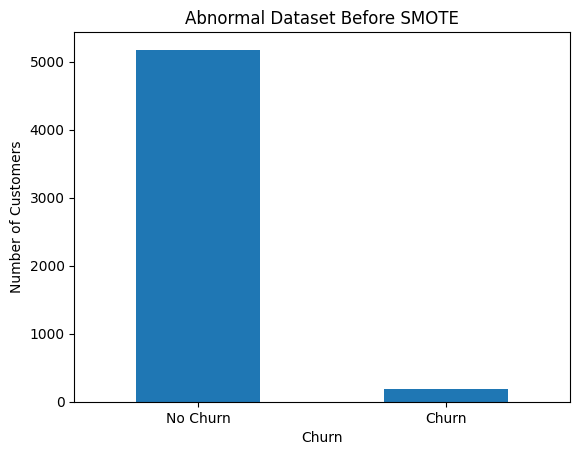

In [8]:
df["Churn"].value_counts().plot(kind="bar")

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Abnormal Dataset Before SMOTE")
plt.xticks([0, 1], ["No Churn", "Churn"], rotation=0)

plt.show()

In [9]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [10]:
df = df.dropna()

In [11]:
df = df.drop("customerID", axis=1)

In [12]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [13]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [14]:
X = pd.get_dummies(X, drop_first=True)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Churn
0    4130
1     150
Name: count, dtype: int64


In [18]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [19]:
print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Churn
1    4130
0    4130
Name: count, dtype: int64


In [20]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [21]:
y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7514018691588785


In [23]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.10921501706484642


In [24]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.8648648648648649


In [25]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.19393939393939394


In [26]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[772 261]
 [  5  32]]


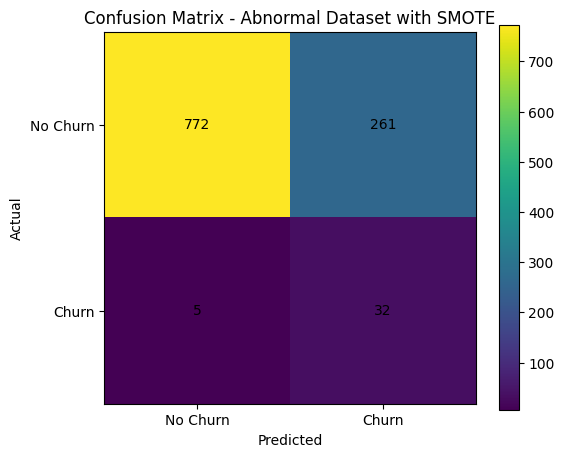

In [27]:
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Abnormal Dataset with SMOTE")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [28]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

In [29]:
auc = roc_auc_score(
    y_test,
    y_prob
)

print("AUC:", auc)

AUC: 0.867154182255828


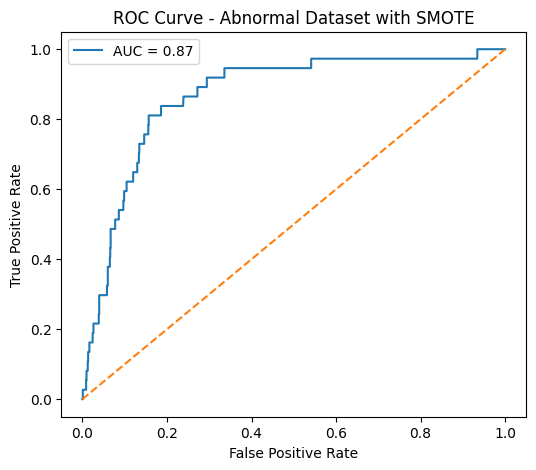

In [30]:
plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label="AUC = {:.2f}".format(auc)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Abnormal Dataset with SMOTE")

plt.legend()
plt.show()

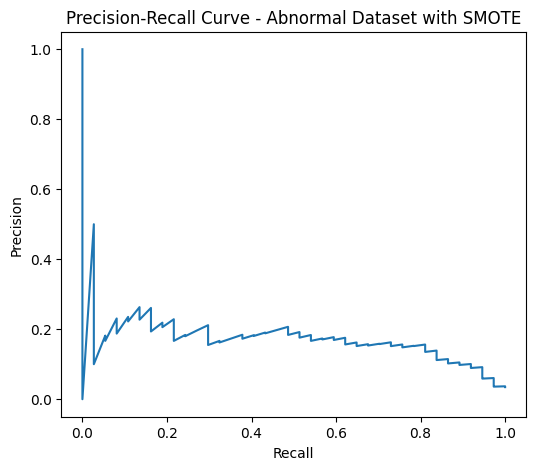

In [31]:
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Abnormal Dataset with SMOTE")

plt.show()